# Polarimetry-to-structure reconstruction

This notebook connects two-dimensional synthetic polarimetry-like fields to the structural variables used by the remodeling model:

\[
\alpha(X,Y),\;R(X,Y)
\longrightarrow
\mathbf a_0(X,Y),\;\beta(X,Y),\;
\mathbf A(X,Y)=\mathbf a_0\otimes\mathbf a_0.
\]

The pipeline is deliberately explicit about which fields are prescribed and which structural quantities are inferred. The azimuth map defines a head-tail symmetric orientation. The retardance map is converted to a bounded structural-order **proxy** through a stated calibration, then optionally modulated by local nematic coherence.

## Objectives

1. Generate a reproducible synthetic polarimetric dataset with noise and invalid pixels.
2. Reconstruct model-ready orientation vectors and structural tensors.
3. Build a bounded structural-order field from retardance and local orientation coherence.
4. Verify nematic invariance, projector properties, masks, and physical bounds.
5. Quantify reconstruction error against known synthetic ground truth.
6. Export the fields in a format ready for the spatial remodeling solver.

## Scientific interpretation and limitation

For a linear retarder, optical phase delay depends on birefringence, specimen thickness, and wavelength. Therefore, retardance is **not** universally identical to a mechanical anisotropy parameter or to an absolute biological order parameter.

Version 0.3 uses an explicit monotone calibration

\[
\widehat R=\operatorname{clip}\left(
\frac{R-R_{\min}}{R_{\max}-R_{\min}},0,1
\right),
\qquad
\beta_R=\beta_{\min}+
(\beta_{\max}-\beta_{\min})\widehat R^{\,p}.
\]

The final structural-order proxy can include local nematic coherence:

\[
q=\frac{\left\langle w\,e^{2i\alpha}\right\rangle}
{\left\langle w\right\rangle},
\qquad
c=|q|,
\qquad
\beta=\beta_R c.
\]

The doubled angle makes the calculation invariant under \(\alpha\mapsto\alpha+\pi\), as required for undirected fibers.

In [1]:
from __future__ import annotations

import csv
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_repository_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Could not locate the repository root.")


REPOSITORY_ROOT = find_repository_root(Path.cwd().resolve())
SOURCE_DIRECTORY = REPOSITORY_ROOT / "src"
if str(SOURCE_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIRECTORY))

from anisotropic_remodeling import (  # noqa: E402
    RetardanceCalibration,
    local_nematic_coherence,
    nematic_angle_difference,
    polarimetry_to_structure,
)

np.set_printoptions(precision=6, suppress=True)
print(f"Repository root: {REPOSITORY_ROOT}")
print(f"NumPy version: {np.__version__}")

Repository root: D:\Anisotropic-Soft-Tissue-Remodeling
NumPy version: 1.24.3


## 1. Reproducible synthetic measurement

In [2]:
rng = np.random.default_rng(20260713)

nx, ny = 121, 81
half_width, half_height = 1.5, 1.0
x_coordinates = np.linspace(-half_width, half_width, nx)
y_coordinates = np.linspace(-half_height, half_height, ny)
x, y = np.meshgrid(x_coordinates, y_coordinates, indexing="xy")

tissue_mask = (x / half_width) ** 2 + (y / half_height) ** 2 <= 0.96**2

true_azimuth = np.mod(
    np.deg2rad(
        42.0
        + 28.0 * np.sin(np.pi * x / (2.0 * half_width))
        * np.cos(np.pi * y / (2.0 * half_height))
        + 10.0 * np.tanh(y / 0.28)
    ),
    np.pi,
)

defect = np.exp(
    -0.5
    * (
        ((x - 0.35) / 0.32) ** 2
        + ((y + 0.18) / 0.24) ** 2
    )
)
edge_penalty = 0.10 * ((x / half_width) ** 2 + (y / half_height) ** 2)
true_retardance_order = np.clip(0.82 - 0.58 * defect - edge_penalty, 0.05, 0.95)

calibration = RetardanceCalibration(
    lower_retardance=0.04,
    upper_retardance=0.90,
    beta_min=0.05,
    beta_max=0.95,
    exponent=1.30,
)

normalized_true_order = (
    (true_retardance_order - calibration.beta_min)
    / (calibration.beta_max - calibration.beta_min)
)
true_retardance = calibration.lower_retardance + (
    calibration.upper_retardance - calibration.lower_retardance
) * np.clip(normalized_true_order, 0.0, 1.0) ** (1.0 / calibration.exponent)

angle_noise_std_deg = 1.0 + 7.0 * (1.0 - true_retardance_order)
observed_azimuth = true_azimuth + np.deg2rad(
    rng.normal(0.0, angle_noise_std_deg, size=true_azimuth.shape)
)
observed_retardance = true_retardance + rng.normal(0.0, 0.015, size=true_retardance.shape)

artifact = ((x + 0.72) / 0.18) ** 2 + ((y - 0.42) / 0.13) ** 2 <= 1.0
observed_retardance[artifact] = rng.uniform(0.0, 0.03, size=np.count_nonzero(artifact))
observed_azimuth[artifact] = rng.uniform(0.0, np.pi, size=np.count_nonzero(artifact))

observed_azimuth[~tissue_mask] = np.nan
observed_retardance[~tissue_mask] = np.nan

raw_data_path = REPOSITORY_ROOT / "data" / "synthetic" / "polarimetry_maps.npz"
raw_data_path.parent.mkdir(parents=True, exist_ok=True)
np.savez_compressed(
    raw_data_path,
    x=x,
    y=y,
    azimuth_rad=observed_azimuth,
    retardance=observed_retardance,
    tissue_mask=tissue_mask,
    true_azimuth_rad=true_azimuth,
    true_retardance_order=true_retardance_order,
)

print(f"Grid shape: {x.shape}")
print(f"Tissue pixels: {np.count_nonzero(tissue_mask)}")
print(f"Synthetic artifact pixels: {np.count_nonzero(artifact & tissue_mask)}")
print(f"Saved raw maps to: {raw_data_path.relative_to(REPOSITORY_ROOT)}")

Grid shape: (81, 121)
Tissue pixels: 6951
Synthetic artifact pixels: 115
Saved raw maps to: data\synthetic\polarimetry_maps.npz


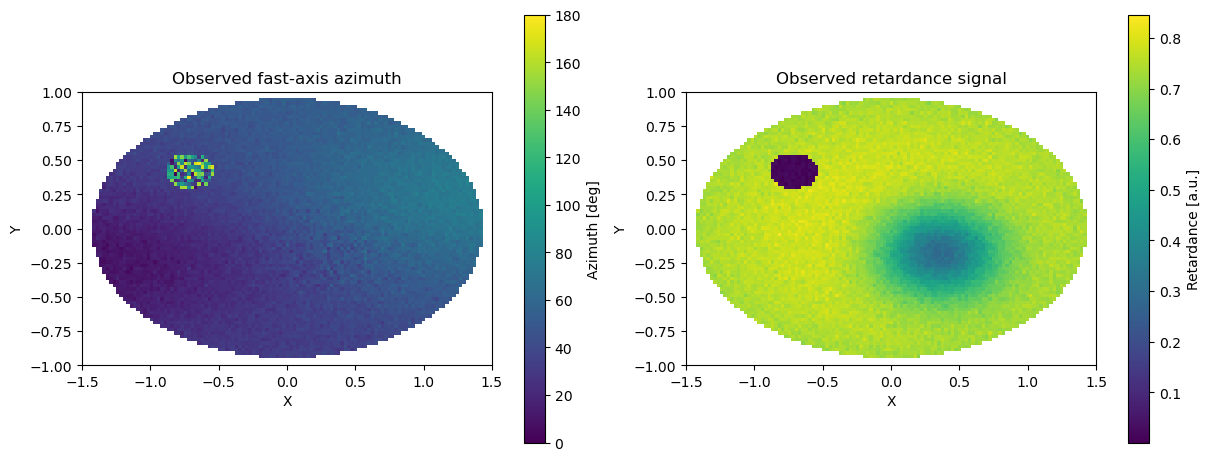

In [3]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

azimuth_image = axes[0].imshow(
    np.rad2deg(observed_azimuth),
    origin="lower",
    extent=(-half_width, half_width, -half_height, half_height),
    vmin=0.0,
    vmax=180.0,
    aspect="equal",
)
axes[0].set(title="Observed fast-axis azimuth", xlabel="X", ylabel="Y")
figure.colorbar(azimuth_image, ax=axes[0], label="Azimuth [deg]")

retardance_image = axes[1].imshow(
    observed_retardance,
    origin="lower",
    extent=(-half_width, half_width, -half_height, half_height),
    aspect="equal",
)
axes[1].set(title="Observed retardance signal", xlabel="X", ylabel="Y")
figure.colorbar(retardance_image, ax=axes[1], label="Retardance [a.u.]")

plt.show()

## 2. Optical-to-structural conversion

The conversion requires four explicit synthetic-calibration choices:

- calibration limits \(R_{\min}\) and \(R_{\max}\);
- calibration exponent \(p\);
- minimum reliable retardance;
- orientation offset between the synthetic fast-axis field and the modeled fiber axis.

The reference benchmark uses zero orientation offset; alternative synthetic offsets can be prescribed to test convention sensitivity.

In [4]:
minimum_valid_retardance = 0.08
coherence_window = 9
orientation_offset_rad = 0.0

reconstruction = polarimetry_to_structure(
    observed_azimuth,
    observed_retardance,
    calibration,
    orientation_offset_rad=orientation_offset_rad,
    minimum_valid_retardance=minimum_valid_retardance,
    external_valid_mask=tissue_mask,
    coherence_window=coherence_window,
    combine_with_coherence=True,
)

valid = reconstruction.valid_mask
print(f"Valid reconstructed pixels: {np.count_nonzero(valid)}")
print(f"Rejected pixels: {valid.size - np.count_nonzero(valid)}")
print(f"Mean retardance-order proxy: {np.nanmean(reconstruction.retardance_order):.6f}")
print(f"Mean local coherence: {np.nanmean(reconstruction.local_coherence):.6f}")
print(f"Mean combined beta: {np.nanmean(reconstruction.structural_order):.6f}")

Valid reconstructed pixels: 6836
Rejected pixels: 2965
Mean retardance-order proxy: 0.708543
Mean local coherence: 0.992382
Mean combined beta: 0.703541


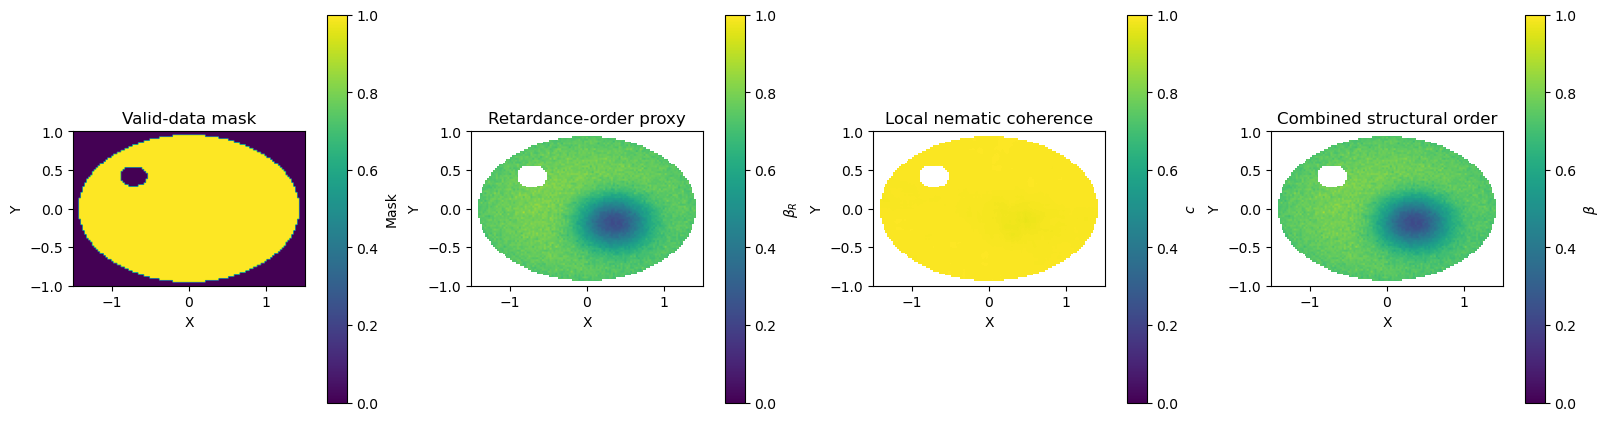

In [5]:
figure, axes = plt.subplots(1, 4, figsize=(16, 4.1), constrained_layout=True)
fields = (
    (reconstruction.valid_mask.astype(float), "Valid-data mask", "Mask"),
    (reconstruction.retardance_order, "Retardance-order proxy", r"$\beta_R$"),
    (reconstruction.local_coherence, "Local nematic coherence", r"$c$"),
    (reconstruction.structural_order, "Combined structural order", r"$\beta$")
)

for axis, (field, title, label) in zip(axes, fields, strict=True):
    image = axis.imshow(
        field,
        origin="lower",
        extent=(-half_width, half_width, -half_height, half_height),
        vmin=0.0,
        vmax=1.0,
        aspect="equal",
    )
    axis.set(title=title, xlabel="X", ylabel="Y")
    figure.colorbar(image, ax=axis, label=label)

plt.show()

## 3. Model-ready fiber field

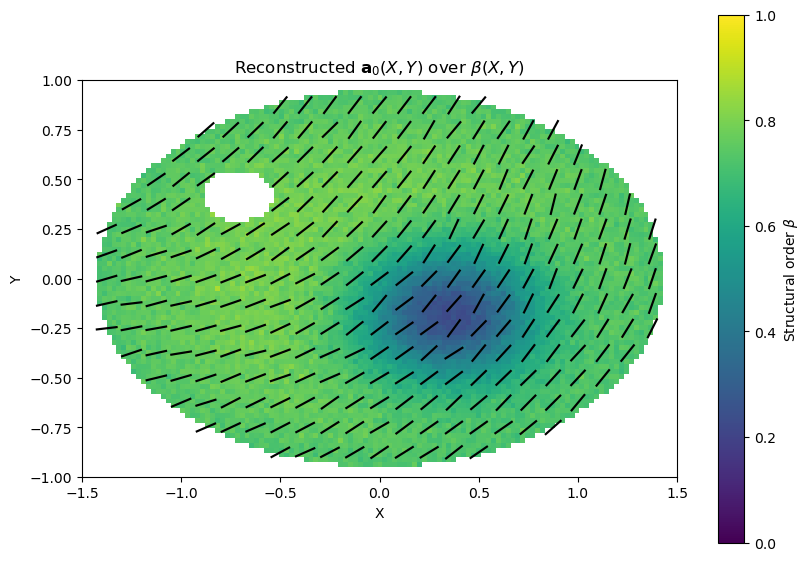

In [6]:
stride = 5
sample = np.s_[::stride, ::stride]
quiver_mask = valid[sample]

figure, axis = plt.subplots(figsize=(8, 5.5), constrained_layout=True)
background = axis.imshow(
    reconstruction.structural_order,
    origin="lower",
    extent=(-half_width, half_width, -half_height, half_height),
    vmin=0.0,
    vmax=1.0,
    aspect="equal",
)

sample_x = x[sample][quiver_mask]
sample_y = y[sample][quiver_mask]
sample_a = reconstruction.fiber_direction[sample][quiver_mask]
axis.quiver(
    sample_x,
    sample_y,
    sample_a[:, 0],
    sample_a[:, 1],
    angles="xy",
    scale_units="xy",
    scale=9.0,
    pivot="middle",
    headwidth=0.0,
    headlength=0.0,
    headaxislength=0.0,
)
axis.set(
    title=r"Reconstructed $\mathbf{a}_0(X,Y)$ over $\beta(X,Y)$",
    xlabel="X",
    ylabel="Y",
)
figure.colorbar(background, ax=axis, label=r"Structural order $\beta$")
plt.show()

Each valid pixel produces the structural tensor

\[
\mathbf A=
\begin{bmatrix}
a_x^2 & a_xa_y\\
a_xa_y & a_y^2
\end{bmatrix}.
\]

For a single perfectly resolved fiber family, \(\mathbf A\) is a symmetric rank-one projector with

\[
\operatorname{tr}\mathbf A=1,
\qquad
\mathbf A^2=\mathbf A.
\]

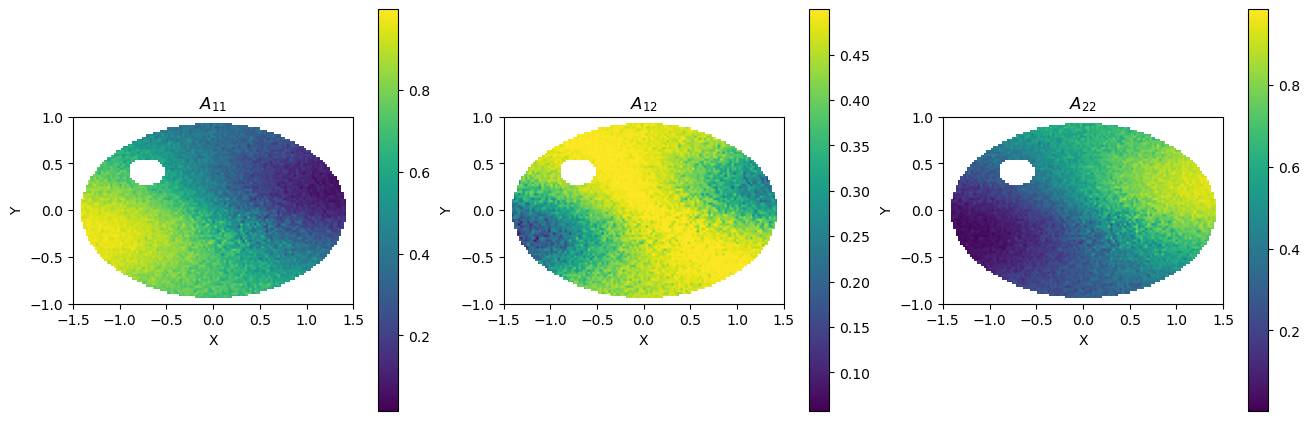

In [7]:
figure, axes = plt.subplots(1, 3, figsize=(13, 4.1), constrained_layout=True)
components = (
    (reconstruction.structure_tensor[..., 0, 0], r"$A_{11}$"),
    (reconstruction.structure_tensor[..., 0, 1], r"$A_{12}$"),
    (reconstruction.structure_tensor[..., 1, 1], r"$A_{22}$"),
)

for axis, (field, title) in zip(axes, components, strict=True):
    image = axis.imshow(
        field,
        origin="lower",
        extent=(-half_width, half_width, -half_height, half_height),
        aspect="equal",
    )
    axis.set(title=title, xlabel="X", ylabel="Y")
    figure.colorbar(image, ax=axis)

plt.show()

## 4. Reconstruction accuracy against synthetic ground truth

In [8]:
true_coherence = local_nematic_coherence(
    true_azimuth,
    window_size=coherence_window,
    weights=np.where(tissue_mask, true_retardance_order, 0.0),
    valid_mask=tissue_mask,
)
true_structural_order = true_retardance_order * true_coherence

angle_error_rad = np.abs(
    nematic_angle_difference(
        reconstruction.azimuth_rad[valid],
        true_azimuth[valid],
    )
)
angle_error_deg = np.rad2deg(angle_error_rad)

retardance_order_error = (
    reconstruction.retardance_order[valid] - true_retardance_order[valid]
)
combined_order_error = (
    reconstruction.structural_order[valid] - true_structural_order[valid]
)

def rmse(values: np.ndarray) -> float:
    return float(np.sqrt(np.mean(values**2)))

metrics = {
    "mean_absolute_angle_error_deg": float(np.mean(angle_error_deg)),
    "angle_error_95th_percentile_deg": float(np.percentile(angle_error_deg, 95.0)),
    "retardance_order_rmse": rmse(retardance_order_error),
    "combined_order_rmse": rmse(combined_order_error),
    "combined_order_mae": float(np.mean(np.abs(combined_order_error))),
}

for name, value in metrics.items():
    print(f"{name}: {value:.6f}")

mean_absolute_angle_error_deg: 2.382698
angle_error_95th_percentile_deg: 6.067743
retardance_order_rmse: 0.018931
combined_order_rmse: 0.019149
combined_order_mae: 0.015332


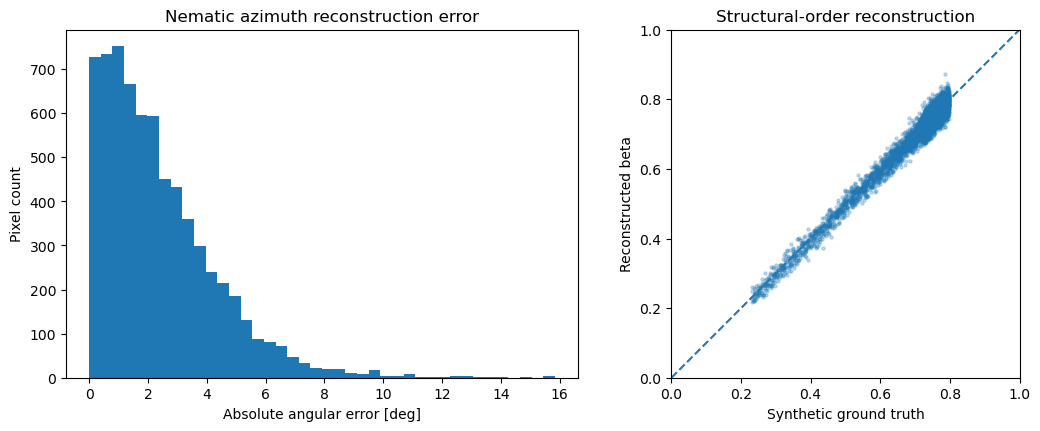

In [9]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)

axes[0].hist(angle_error_deg, bins=40)
axes[0].set(
    title="Nematic azimuth reconstruction error",
    xlabel="Absolute angular error [deg]",
    ylabel="Pixel count",
)

axes[1].scatter(
    true_structural_order[valid],
    reconstruction.structural_order[valid],
    s=5,
    alpha=0.25,
)
comparison_limits = (0.0, 1.0)
axes[1].plot(comparison_limits, comparison_limits, linestyle="--")
axes[1].set(
    title="Structural-order reconstruction",
    xlabel="Synthetic ground truth",
    ylabel="Reconstructed beta",
    xlim=comparison_limits,
    ylim=comparison_limits,
    aspect="equal",
)

plt.show()

## 5. Mathematical and physical checks

In [10]:
valid_tensor = reconstruction.structure_tensor[valid]
trace_error = np.max(np.abs(np.trace(valid_tensor, axis1=-2, axis2=-1) - 1.0))
symmetry_error = np.max(np.abs(valid_tensor - np.swapaxes(valid_tensor, -1, -2)))
idempotence_error = np.max(
    np.linalg.norm(valid_tensor @ valid_tensor - valid_tensor, axis=(-2, -1))
)
fiber_norm_error = np.max(
    np.abs(np.linalg.norm(reconstruction.fiber_direction[valid], axis=-1) - 1.0)
)

checks = {
    "non-empty valid mask": bool(np.any(valid)),
    "unit fiber directions": bool(fiber_norm_error < 1.0e-12),
    "symmetric structure tensor": bool(symmetry_error < 1.0e-12),
    "unit tensor trace": bool(trace_error < 1.0e-12),
    "projector idempotence": bool(idempotence_error < 1.0e-12),
    "bounded retardance order": bool(
        np.all((reconstruction.retardance_order[valid] >= 0.0)
               & (reconstruction.retardance_order[valid] <= 1.0))
    ),
    "bounded combined order": bool(
        np.all((reconstruction.structural_order[valid] >= 0.0)
               & (reconstruction.structural_order[valid] <= 1.0))
    ),
    "invalid pixels represented by NaN": bool(
        np.all(np.isnan(reconstruction.structural_order[~valid]))
    ),
}

for name, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'} — {name}")

print(f"Maximum fiber-norm error: {fiber_norm_error:.3e}")
print(f"Maximum tensor symmetry error: {symmetry_error:.3e}")
print(f"Maximum tensor trace error: {trace_error:.3e}")
print(f"Maximum projector error: {idempotence_error:.3e}")
assert all(checks.values())

PASS — non-empty valid mask
PASS — unit fiber directions
PASS — symmetric structure tensor
PASS — unit tensor trace
PASS — projector idempotence
PASS — bounded retardance order
PASS — bounded combined order
PASS — invalid pixels represented by NaN
Maximum fiber-norm error: 1.110e-16
Maximum tensor symmetry error: 0.000e+00
Maximum tensor trace error: 2.220e-16
Maximum projector error: 3.640e-16


## 6. Nematic invariance test

A fiber has no arrowhead. Replacing any subset of azimuths by \(\alpha+\pi\) must leave \(\mathbf a_0\otimes\mathbf a_0\), local coherence, and \(\beta\) unchanged.

In [11]:
random_pi_flips = rng.integers(0, 2, size=observed_azimuth.shape) * np.pi
flipped_reconstruction = polarimetry_to_structure(
    observed_azimuth + random_pi_flips,
    observed_retardance,
    calibration,
    orientation_offset_rad=orientation_offset_rad,
    minimum_valid_retardance=minimum_valid_retardance,
    external_valid_mask=tissue_mask,
    coherence_window=coherence_window,
    combine_with_coherence=True,
)

tensor_flip_error = np.nanmax(
    np.abs(
        reconstruction.structure_tensor
        - flipped_reconstruction.structure_tensor
    )
)
coherence_flip_error = np.nanmax(
    np.abs(reconstruction.local_coherence - flipped_reconstruction.local_coherence)
)
beta_flip_error = np.nanmax(
    np.abs(reconstruction.structural_order - flipped_reconstruction.structural_order)
)

print(f"Maximum structure-tensor change: {tensor_flip_error:.3e}")
print(f"Maximum coherence change: {coherence_flip_error:.3e}")
print(f"Maximum beta change: {beta_flip_error:.3e}")

assert tensor_flip_error < 1.0e-12
assert coherence_flip_error < 1.0e-12
assert beta_flip_error < 1.0e-12

Maximum structure-tensor change: 6.661e-16
Maximum coherence change: 1.210e-14
Maximum beta change: 8.549e-15


## 7. Calibration sensitivity

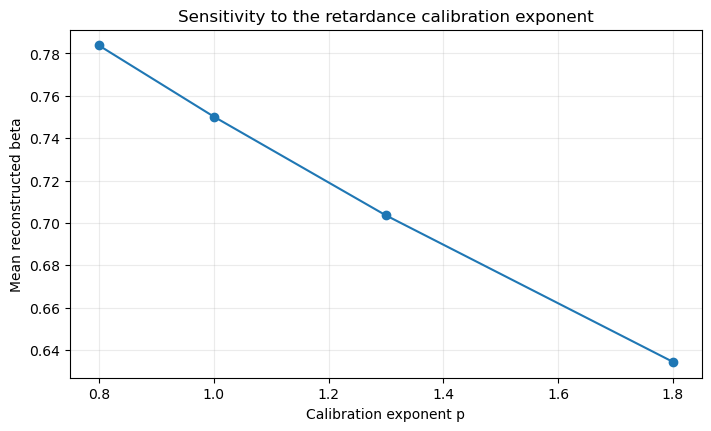

p=0.8: mean beta=0.783723
p=1.0: mean beta=0.750161
p=1.3: mean beta=0.703541
p=1.8: mean beta=0.634398


In [12]:
exponents = np.array([0.8, 1.0, 1.3, 1.8])
mean_beta_by_exponent = []

for exponent in exponents:
    trial_calibration = RetardanceCalibration(
        lower_retardance=calibration.lower_retardance,
        upper_retardance=calibration.upper_retardance,
        beta_min=calibration.beta_min,
        beta_max=calibration.beta_max,
        exponent=float(exponent),
    )
    trial = polarimetry_to_structure(
        observed_azimuth,
        observed_retardance,
        trial_calibration,
        minimum_valid_retardance=minimum_valid_retardance,
        external_valid_mask=tissue_mask,
        coherence_window=coherence_window,
    )
    mean_beta_by_exponent.append(float(np.nanmean(trial.structural_order)))

figure, axis = plt.subplots(figsize=(7, 4.2), constrained_layout=True)
axis.plot(exponents, mean_beta_by_exponent, marker="o")
axis.set(
    title="Sensitivity to the retardance calibration exponent",
    xlabel="Calibration exponent p",
    ylabel="Mean reconstructed beta",
)
axis.grid(True, alpha=0.25)
plt.show()

for exponent, mean_beta in zip(exponents, mean_beta_by_exponent, strict=True):
    print(f"p={exponent:.1f}: mean beta={mean_beta:.6f}")

## 8. Export model-ready fields

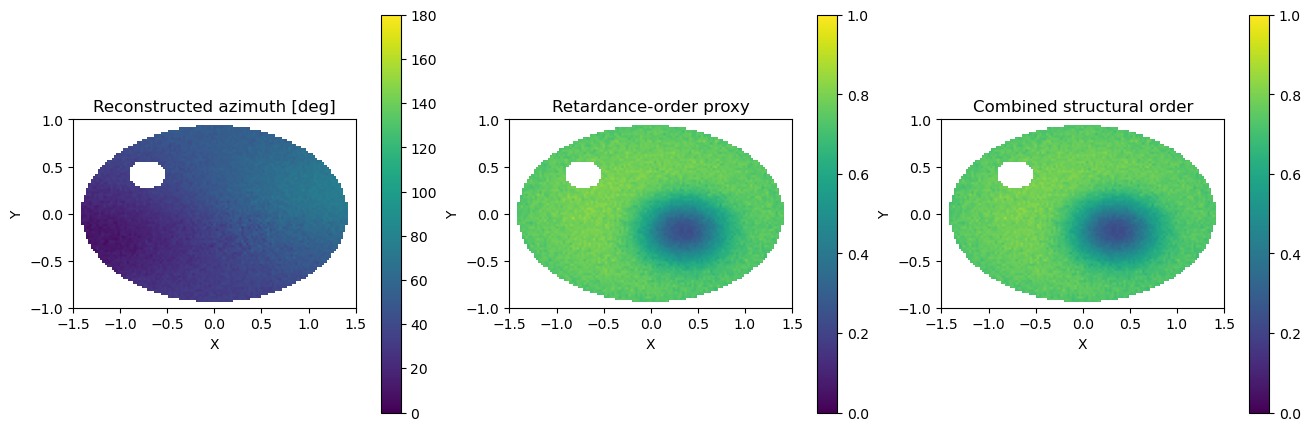

Saved fields: results\data\polarimetry_to_structure_fields.npz
Saved metrics: results\data\polarimetry_reconstruction_metrics.csv
Saved figure: results\figures\polarimetry_to_structure_summary.png


In [13]:
output_directory = REPOSITORY_ROOT / "results" / "data"
figure_directory = REPOSITORY_ROOT / "results" / "figures"
output_directory.mkdir(parents=True, exist_ok=True)
figure_directory.mkdir(parents=True, exist_ok=True)

field_output_path = output_directory / "polarimetry_to_structure_fields.npz"
np.savez_compressed(
    field_output_path,
    x=x,
    y=y,
    observed_azimuth_rad=observed_azimuth,
    observed_retardance=observed_retardance,
    valid_mask=reconstruction.valid_mask,
    azimuth_rad=reconstruction.azimuth_rad,
    fiber_direction=reconstruction.fiber_direction,
    structure_tensor=reconstruction.structure_tensor,
    retardance_order=reconstruction.retardance_order,
    local_coherence=reconstruction.local_coherence,
    structural_order=reconstruction.structural_order,
)

metrics_output_path = output_directory / "polarimetry_reconstruction_metrics.csv"
with metrics_output_path.open("w", newline="", encoding="utf-8") as stream:
    writer = csv.writer(stream)
    writer.writerow(("metric", "value"))
    writer.writerows(metrics.items())

summary_figure_path = figure_directory / "polarimetry_to_structure_summary.png"
figure, axes = plt.subplots(1, 3, figsize=(13, 4.2), constrained_layout=True)
summary_fields = (
    (np.rad2deg(reconstruction.azimuth_rad), "Reconstructed azimuth [deg]", 0.0, 180.0),
    (reconstruction.retardance_order, "Retardance-order proxy", 0.0, 1.0),
    (reconstruction.structural_order, "Combined structural order", 0.0, 1.0),
)
for axis, (field, title, lower, upper) in zip(axes, summary_fields, strict=True):
    image = axis.imshow(
        field,
        origin="lower",
        extent=(-half_width, half_width, -half_height, half_height),
        vmin=lower,
        vmax=upper,
        aspect="equal",
    )
    axis.set(title=title, xlabel="X", ylabel="Y")
    figure.colorbar(image, ax=axis)
figure.savefig(summary_figure_path, dpi=180)
plt.show()

print(f"Saved fields: {field_output_path.relative_to(REPOSITORY_ROOT)}")
print(f"Saved metrics: {metrics_output_path.relative_to(REPOSITORY_ROOT)}")
print(f"Saved figure: {summary_figure_path.relative_to(REPOSITORY_ROOT)}")

## 9. Applying the pipeline to a new synthetic benchmark

A new benchmark only needs arrays of identical shape:

```python
benchmark = np.load("path/to/synthetic_maps.npz")
alpha = benchmark["azimuth_rad"]
retardance = benchmark["retardance"]
quality_mask = benchmark["valid_mask"]

result = polarimetry_to_structure(
    alpha,
    retardance,
    calibration,
    orientation_offset_rad=prescribed_offset,
    minimum_valid_retardance=prescribed_threshold,
    external_valid_mask=quality_mask,
    coherence_window=prescribed_window,
)
```

All calibration constants, perturbation amplitudes, masks, and random seeds
should be stored with the generated arrays so that the reconstruction can be
repeated exactly.

## Result

The exported arrays are directly compatible with the spatial model:

\[
\mathbf a_0(X,Y,0)=\mathbf a_{\mathrm{syn}}(X,Y),
\qquad
\beta(X,Y,0)=\beta_{\mathrm{syn}}(X,Y).
\]
